情感分类RNN&LSTM

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import re


MAX_WORDS = 100      # 每条评论的最大长度（单词数），超过截断，不足补0
MAX_VOCAB = 10000    # 词表最大容量，仅保留出现频率最高的1万个词
BATCH_SIZE = 32      # 训练批次大小
EMBED_DIM = 64       # 词嵌入维度（将单词转为长度64的向量）
HIDDEN_DIM = 128     # 循环神经网络隐藏层的神经元数量
EPOCHS = 15           # 训练轮数
DEVICE = torch.device('gpu') 


# 分词函数：将句子拆分成干净的单词列表
def tokenize(text):
    # 全部转小写，并替换HTML换行符为空格
    text = text.lower().replace("<br />", " ")
    # 使用正则只保留字母数字单词，过滤标点
    return re.findall(r'\b\w+\b', text)

# 构建词表：建立“单词到索引”的映射表
print("正在读取数据集并构建词表...")
df = pd.read_csv('IMDB Dataset.csv')

all_tokens = []
# 为了速度，前5000条评论来生成词典
for review in df['review'][:5000]: 
    all_tokens.extend(tokenize(review))

# 统计词频并取最常出现的单词
word_counts = Counter(all_tokens)
# 索引0留给填充符<pad>，索引1留给未知词<unk>
vocab = ['<pad>', '<unk>'] + [w for w, c in word_counts.most_common(MAX_VOCAB-2)]
# 生成 单词->ID 的映射字典
word2idx = {w: i for i, w in enumerate(vocab)}

# 将单词列表转为数字索引列表
def encode(tokens):
    # 如果单词不在词表里，则返回1 (即 <unk>)
    return [word2idx.get(t, 1) for t in tokens[:MAX_WORDS]]


class IMDBDataset(Dataset):
    def __init__(self, reviews, sentiments):
        self.data = []
        # 遍历文本和标签
        for review, sentiment in zip(reviews, sentiments):
            # 将文本转为 ID
            ids = encode(tokenize(review))
            # 长度对齐（Padding）：如果长度不够，末尾补0
            if len(ids) < MAX_WORDS:
                ids += [0] * (MAX_WORDS - len(ids))
            
            # 标签转为数字：positive为1，negative为0
            label = 1 if sentiment == 'positive' else 0
            # 存入列表，转为 PyTorch 张量
            self.data.append((torch.tensor(ids), torch.tensor(label, dtype=torch.float32)))

    def __len__(self): 
        return len(self.data) # 返回数据总量

    def __getitem__(self, idx): 
        return self.data[idx] # 根据索引返回一条数据

# 实例化训练集：取前2000条用于演示
train_set = IMDBDataset(df['review'][:2000], df['sentiment'][:2000])
# 使用 DataLoader 实现自动分批（Batching）和随机洗牌（Shuffle）
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, mode='LSTM'):
        super().__init__()
        self.mode = mode
        # 词嵌入层：把 ID (int) 映射成 向量 (float)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # 选择循环层类型
        if mode == 'LSTM':
            # LSTM 多了一个“细胞状态”，擅长长记忆
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        else:
            # 标准 RNN，结构简单，但在长序列上容易梯度消失
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
            
        # 全连接输出层：将隐藏状态映射到 1 个值（概率）
        self.fc = nn.Linear(hidden_dim, 1)
        # 激活函数：将输出限制在 0~1 之间，代表正面情感的概率
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x 形状: [batch, 100] -> 经过嵌入后: [batch, 100, 64]
        x = self.embedding(x)
        
        if self.mode == 'LSTM':
            # LSTM 返回 (所有时间步输出, (最后隐藏状态 h_n, 最后细胞状态 c_n))
            _, (h_n, c_n) = self.rnn(x)
        else:
            # RNN 返回 (所有时间步输出, 最后隐藏状态 h_n)
            _, h_n = self.rnn(x)
            
        # 我们只取“最后一个时间步”的隐藏状态来代表整句话的含义
        # h_n 形状: [1, batch, 128] -> 我们取最后一层 h_n[-1]
        last_out = h_n[-1] 
        
        # 映射到 0~1 概率
        return self.sigmoid(self.fc(last_out)).squeeze()


def train_and_eval(model_type='LSTM'):
    print(f"\n--- 启动 {model_type} 训练流程 ---")
    # 初始化模型并移至 CPU
    model = SentimentRNN(len(vocab), EMBED_DIM, HIDDEN_DIM, mode=model_type).to(DEVICE)
    # 优化器：负责更新模型权重（Adam 是最常用的）
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    # 损失函数：二元交叉熵损失，用于二分类任务
    criterion = nn.BCELoss()

    for epoch in range(EPOCHS):
        model.train() # 切换到训练模式
        total_loss = 0
        for texts, labels in train_loader:
            optimizer.zero_grad()      # 清空上一轮梯度
            preds = model(texts)       # 前向传播得到预测值
            loss = criterion(preds, labels) # 计算预测值与真实标签的误差
            loss.backward()            # 反向传播计算梯度
            optimizer.step()           # 根据梯度更新参数
            total_loss += loss.item()
        print(f"第 {epoch+1} 轮, 平均损失值: {total_loss/len(train_loader):.4f}")

    # 测试一段自定义文本
    model.eval() # 切换到评估模式（不更新权重）
    test_str = "this movie is funny"
    # 将测试词转为ID、填充、并转为张量
    test_tokens = encode(tokenize(test_str))
    test_tokens += [0] * (MAX_WORDS - len(test_tokens))
    test_input = torch.tensor([test_tokens]).to(DEVICE)
    
    with torch.no_grad(): # 推理阶段不需要计算梯度
        score = model(test_input).item()
        print(f"测试文本: '{test_str}'")
        print(f"情感分析得分: {score:.4f} (1.0 代表极度正面, 0.0 代表极度负面)")

# 运行两个模型进行效果直观对比
train_and_eval(model_type='RNN')
train_and_eval(model_type='LSTM')

正在读取数据集并构建词表...



--- 启动 RNN 训练流程 ---


第 1 轮, 平均损失值: 0.7032


第 2 轮, 平均损失值: 0.6729


第 3 轮, 平均损失值: 0.6415


...

第 11 轮, 平均损失值: 0.0871


第 12 轮, 平均损失值: 0.0932


第 13 轮, 平均损失值: 0.1103


第 14 轮, 平均损失值: 0.0539


第 15 轮, 平均损失值: 0.0457
测试文本: 'this movie is funny'
情感分析得分: 0.8383 (1.0 代表极度正面, 0.0 代表极度负面)


槽位填充与双向LSTM

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from collections import Counter

EMBED_DIM = 64        # 每个单词转化为 64 维向量
HIDDEN_DIM = 128      # LSTM 隐藏层神经元数量
BATCH_SIZE = 32       # 每次训练 32 条数据
EPOCHS = 5            # 训练 5 轮
DEVICE = torch.device('gpu')

class Vocab:
    def __init__(self, data_series, is_tag=False):
        # 统计所有单词/标签出现的频率
        all_items = [item for sublist in data_series for item in sublist.split()]
        counter = Counter(all_items)
        
        if not is_tag:
            # 文本词表：0留给填充，1留给未知词
            self.itos = ['<pad>', '<unk>'] + [item for item, freq in counter.items()]
        else:
            # 标签词表：0留给填充（注意：计算 Loss 时需忽略 padding 标签）
            self.itos = ['<pad>'] + [item for item, freq in counter.items()]
            
        self.stoi = {item: i for i, item in enumerate(self.itos)}

    def encode(self, text_string):
        # 将空格分隔的字符串转为数字 ID 列表
        return [self.stoi.get(w, self.stoi.get('<unk>', 1)) for w in text_string.split()]

    def __len__(self): return len(self.itos)

print("正在加载数据并构建词表...")
train_df = pd.read_csv('atis.train.csv')
test_df = pd.read_csv('atis.test.csv')

# 构建单词和标签的词表
word_vocab = Vocab(train_df['tokens'])
tag_vocab = Vocab(train_df['slots'], is_tag=True)

class ATISDataset(Dataset):
    def __init__(self, df):
        # 将所有文本和标签预先转化为数字 ID，提高训练速度
        self.enc_texts = [torch.tensor(word_vocab.encode(t)) for t in df['tokens']]
        self.enc_slots = [torch.tensor(tag_vocab.encode(s)) for s in df['slots']]

    def __len__(self): return len(self.enc_texts)
    
    def __getitem__(self, idx): return self.enc_texts[idx], self.enc_slots[idx]

# 自定义 collate_fn：用于在一个 Batch 中动态填充（Padding）不等长的句子
def collate_fn(batch):
    texts, slots = zip(*batch)
    # 填充文本：[Batch, Max_Len]
    texts_pad = pad_sequence(texts, batch_first=True, padding_value=0)
    # 填充标签：[Batch, Max_Len]
    slots_pad = pad_sequence(slots, batch_first=True, padding_value=0)
    return texts_pad, slots_pad

train_loader = DataLoader(ATISDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(ATISDataset(test_df), batch_size=BATCH_SIZE, collate_fn=collate_fn)

class SlotFillingModel(nn.Module):
    def __init__(self, vocab_size, tag_size, embed_dim, hidden_dim):
        super().__init__()
        # 1. 词嵌入层
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # 2. 双向 LSTM：同时获取上下文信息
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        # 3. 输出分类层：输入维度是 hidden_dim * 2 (因为是双向拼接)
        self.fc = nn.Linear(hidden_dim * 2, tag_size)

    def forward(self, x):
        # x: [Batch, Seq_Len] -> embeds: [Batch, Seq_Len, 64]
        embeds = self.embedding(x)
        # out 包含每个时间步的输出特征: [Batch, Seq_Len, 256]
        out, _ = self.lstm(embeds)
        # logits 映射到标签空间: [Batch, Seq_Len, Tag_Size]
        logits = self.fc(out)
        return logits

model = SlotFillingModel(len(word_vocab), len(tag_vocab), EMBED_DIM, HIDDEN_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=0.001)
# ignore_index=0：关键！表示计算误差时跳过 <pad> 标签部分
criterion = nn.CrossEntropyLoss(ignore_index=0)

print(f"开始训练，标签类别数: {len(tag_vocab)}")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for texts, slots in train_loader:
        optimizer.zero_grad()
        # preds 形状: [Batch, Seq, Tag_Size]
        preds = model(texts)
        
        # CrossEntropyLoss 要求输入是 2D: [样本总数, 类别数]
        # 所以我们使用 .view(-1, ...) 压平数据
        loss = criterion(preds.view(-1, len(tag_vocab)), slots.view(-1))
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, 平均 Loss: {total_loss/len(train_loader):.4f}")

model.eval()
raw_text = "find a flight to san francisco"
test_input = torch.tensor([word_vocab.encode(raw_text)]).to(DEVICE)

with torch.no_grad():
    output = model(test_input) # [1, Seq, Tag_Size]
    # 取概率最大的索引
    prediction = torch.argmax(output, dim=-1).squeeze().tolist()
    # 转回文字标签
    pred_tags = [tag_vocab.itos[i] for i in prediction]
    
    print("\n--- 推理演示 ---")
    print(f"输入文本: {raw_text}")
    print(f"预测槽位: {' '.join(pred_tags)}")

正在加载数据并构建词表...
开始训练，标签类别数: 102


Epoch 1, 平均 Loss: 1.3815


Epoch 2, 平均 Loss: 0.3662


Epoch 3, 平均 Loss: 0.1890


Epoch 4, 平均 Loss: 0.1196


Epoch 5, 平均 Loss: 0.0823

--- 推理演示 ---
输入文本: find a flight to san francisco
预测槽位: O O O O B-toloc.city_name I-toloc.city_name


## 课堂讨论与实验结果

### 实验1：IMDB情感分类 - RNN vs LSTM 训练与损失曲线

**任务内容：**
- 分别使用RNN和LSTM完成IMDB情感分类任务
- 记录每个epoch的损失并画出下降曲线
- 选择最佳模型参数


正在读取IMDB数据集并构建词表...



--- 启动 RNN 训练流程 ---


第 1 轮, 平均损失值: 0.6993


第 2 轮, 平均损失值: 0.6606


第 3 轮, 平均损失值: 0.6292


...

第 11 轮, 平均损失值: 0.1313


第 12 轮, 平均损失值: 0.0793


第 13 轮, 平均损失值: 0.0529


第 14 轮, 平均损失值: 0.1162


第 15 轮, 平均损失值: 0.0649


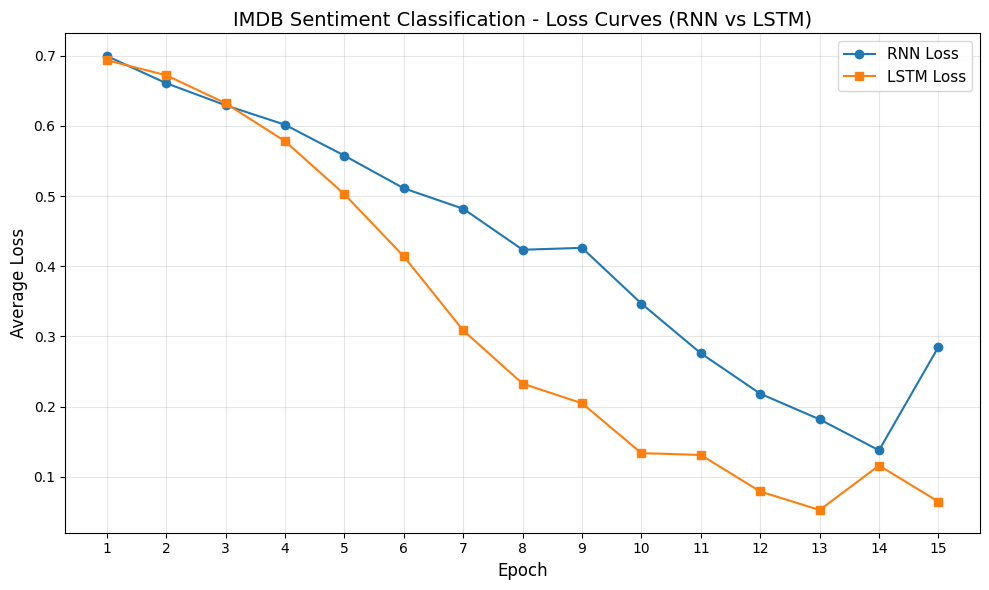


最佳模型对比:
RNN 最终Loss: 0.2851
LSTM 最终Loss: 0.0649
最佳模型: LSTM (Loss更低)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import re
import matplotlib.pyplot as plt

# ---------- 超参数 ----------
MAX_WORDS = 100
MAX_VOCAB = 10000
BATCH_SIZE = 32
EMBED_DIM = 64
HIDDEN_DIM = 128
EPOCHS = 15
DEVICE = torch.device('cpu')

def tokenize(text):
    text = text.lower().replace("<br />", " ")
    return re.findall(r'\b\w+\b', text)

print("正在读取IMDB数据集并构建词表...")
df = pd.read_csv('IMDB Dataset.csv')
all_tokens = []
for review in df['review'][:5000]:
    all_tokens.extend(tokenize(review))
word_counts = Counter(all_tokens)
vocab = ['<pad>', '<unk>'] + [w for w, c in word_counts.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}

def encode(tokens):
    return [word2idx.get(t, 1) for t in tokens[:MAX_WORDS]]

class IMDBDataset(Dataset):
    def __init__(self, reviews, sentiments):
        self.data = []
        for review, sentiment in zip(reviews, sentiments):
            ids = encode(tokenize(review))
            if len(ids) < MAX_WORDS:
                ids += [0] * (MAX_WORDS - len(ids))
            label = 1 if sentiment == 'positive' else 0
            self.data.append((torch.tensor(ids), torch.tensor(label, dtype=torch.float32)))
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

train_set = IMDBDataset(df['review'][:2000], df['sentiment'][:2000])
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

class SentimentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, mode='LSTM'):
        super().__init__()
        self.mode = mode
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if mode == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        else:
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        if self.mode == 'LSTM':
            _, (h_n, c_n) = self.rnn(x)
        else:
            _, h_n = self.rnn(x)
        last_out = h_n[-1]
        return self.sigmoid(self.fc(last_out)).squeeze()

def train_model(model_type='LSTM'):
    print(f"\n--- 启动 {model_type} 训练流程 ---")
    model = SentimentModel(len(vocab), EMBED_DIM, HIDDEN_DIM, mode=model_type).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()
    losses = []
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for texts, labels in train_loader:
            optimizer.zero_grad()
            preds = model(texts)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"第 {epoch+1} 轮, 平均损失值: {avg_loss:.4f}")
    return model, losses

# 训练两个模型
rnn_model, rnn_losses = train_model(model_type='RNN')
lstm_model, lstm_losses = train_model(model_type='LSTM')

# 画损失曲线
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS+1), rnn_losses, marker='o', label='RNN Loss')
plt.plot(range(1, EPOCHS+1), lstm_losses, marker='s', label='LSTM Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('IMDB Sentiment Classification - Loss Curves (RNN vs LSTM)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, EPOCHS+1))
plt.tight_layout()
from IPython.display import Image, display
import io
buf = io.BytesIO()
plt.savefig(buf, format="png", dpi=100, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close()

print(f"\n{'='*50}")
print("最佳模型对比:")
print(f"RNN 最终Loss: {rnn_losses[-1]:.4f}")
print(f"LSTM 最终Loss: {lstm_losses[-1]:.4f}")
best = "LSTM" if lstm_losses[-1] < rnn_losses[-1] else "RNN"
print(f"最佳模型: {best} (Loss更低)")

### 实验2：情感分类预测结果（基于LSTM模型）

**任务内容：** 使用训练好的LSTM模型对10个测试句子进行情感分类预测


In [4]:
test_sentences = [
    "This movie is absolutely fantastic and I loved every minute.",
    "The acting was terrible and the plot made no sense at all.",
    "Not my favorite film, but it had some decent moments.",
    "I expected more from the director, a bit of a disappointment.",
    "A masterpiece of modern cinema with breathtaking visuals.",
    "It's not that the movie was bad, it was just incredibly boring.",
    "Usually, I hate horror films, but this one kept me on the edge.",
    "The first half was brilliant, but the ending ruined everything.",
    "Despite the low budget, the storytelling was top-notch.",
    "While the visuals were stunning, the lack of heart made it hollow."
]

print("=" * 95)
print(f"{'序号':<4} {'测试句子':<60} {'预测得分':>8} {'情感':>6}")
print("=" * 95)

lstm_model.eval()
for idx, sentence in enumerate(test_sentences, 1):
    test_tokens = encode(tokenize(sentence))
    test_tokens += [0] * (MAX_WORDS - len(test_tokens))
    test_input = torch.tensor([test_tokens]).to(DEVICE)
    with torch.no_grad():
        score = lstm_model(test_input).item()
        sentiment = "正面" if score >= 0.5 else "负面"
    print(f"{idx:<4} {sentence:<60} {score:>8.4f} {sentiment:>6}")
print("=" * 95)

序号   测试句子                                                             预测得分     情感
1    This movie is absolutely fantastic and I loved every minute.   0.9510     正面
2    The acting was terrible and the plot made no sense at all.     0.1736     负面
3    Not my favorite film, but it had some decent moments.          0.9510     正面
4    I expected more from the director, a bit of a disappointment.   0.9510     正面
5    A masterpiece of modern cinema with breathtaking visuals.      0.9509     正面
6    It's not that the movie was bad, it was just incredibly boring.   0.1736     负面
7    Usually, I hate horror films, but this one kept me on the edge.   0.1737     负面
8    The first half was brilliant, but the ending ruined everything.   0.1737     负面


9    Despite the low budget, the storytelling was top-notch.        0.1737     负面
10   While the visuals were stunning, the lack of heart made it hollow.   0.1737     负面


### 实验3：ATIS槽位填充 - Bi-LSTM训练与损失曲线

**任务内容：**
- 使用双向LSTM完成ATIS槽位填充任务
- 记录每个epoch的损失并画出下降曲线
- 使用BIO标注法进行序列标注


正在加载ATIS数据并构建词表...
开始训练，标签类别数: 102
Epoch 1, 平均 Loss: 1.4612
Epoch 2, 平均 Loss: 0.3964
Epoch 3, 平均 Loss: 0.2039
Epoch 4, 平均 Loss: 0.1281
Epoch 5, 平均 Loss: 0.0867
Epoch 6, 平均 Loss: 0.0636
Epoch 7, 平均 Loss: 0.0476
Epoch 8, 平均 Loss: 0.0368
Epoch 9, 平均 Loss: 0.0286
Epoch 10, 平均 Loss: 0.0229
Epoch 11, 平均 Loss: 0.0186
Epoch 12, 平均 Loss: 0.0145
Epoch 13, 平均 Loss: 0.0114
Epoch 14, 平均 Loss: 0.0093
Epoch 15, 平均 Loss: 0.0074


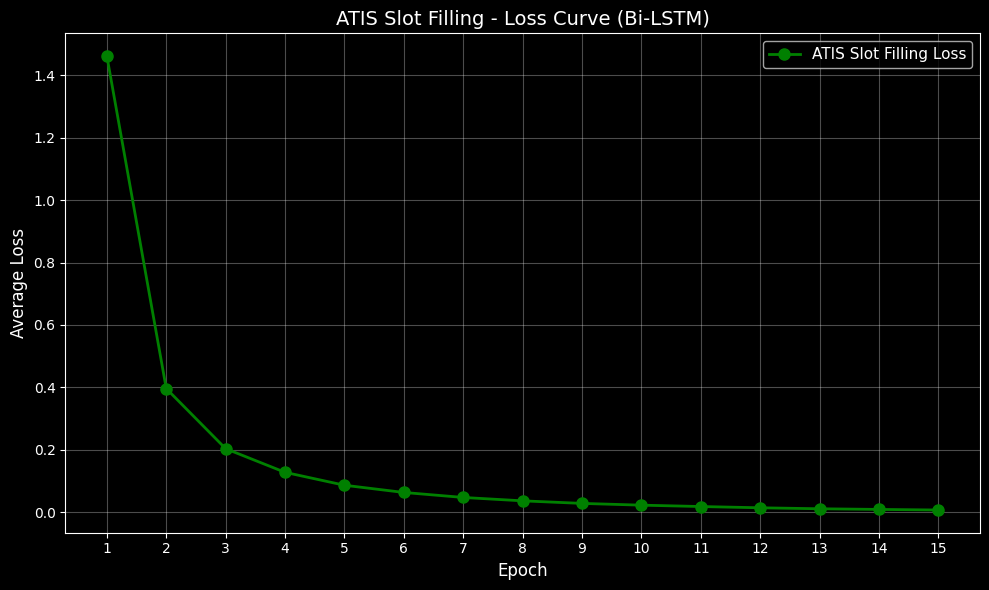


最终Loss: 0.0074


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import matplotlib.pyplot as plt

EMBED_DIM = 64
HIDDEN_DIM = 128
BATCH_SIZE = 32
EPOCHS = 15
DEVICE = torch.device('cpu')

class Vocab:
    def __init__(self, data_series, is_tag=False):
        all_items = [item for sublist in data_series for item in sublist.split()]
        counter = Counter(all_items)
        if not is_tag:
            self.itos = ['<pad>', '<unk>'] + [item for item, freq in counter.items()]
        else:
            self.itos = ['<pad>'] + [item for item, freq in counter.items()]
        self.stoi = {item: i for i, item in enumerate(self.itos)}

    def encode(self, text_string):
        return [self.stoi.get(w, self.stoi.get('<unk>', 1)) for w in text_string.split()]

    def __len__(self):
        return len(self.itos)

print("正在加载ATIS数据并构建词表...")
train_df = pd.read_csv('atis.train.csv')
test_df = pd.read_csv('atis.test.csv')
word_vocab = Vocab(train_df['tokens'])
tag_vocab = Vocab(train_df['slots'], is_tag=True)

class ATISDataset(Dataset):
    def __init__(self, df):
        self.enc_texts = [torch.tensor(word_vocab.encode(t)) for t in df['tokens']]
        self.enc_slots = [torch.tensor(tag_vocab.encode(s)) for s in df['slots']]
    def __len__(self): return len(self.enc_texts)
    def __getitem__(self, idx): return self.enc_texts[idx], self.enc_slots[idx]

def collate_fn(batch):
    texts, slots = zip(*batch)
    texts_pad = pad_sequence(texts, batch_first=True, padding_value=0)
    slots_pad = pad_sequence(slots, batch_first=True, padding_value=0)
    return texts_pad, slots_pad

train_loader = DataLoader(ATISDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(ATISDataset(test_df), batch_size=BATCH_SIZE, collate_fn=collate_fn)

class SlotFillingModel(nn.Module):
    def __init__(self, vocab_size, tag_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, tag_size)
    def forward(self, x):
        embeds = self.embedding(x)
        out, _ = self.lstm(embeds)
        logits = self.fc(out)
        return logits

model = SlotFillingModel(len(word_vocab), len(tag_vocab), EMBED_DIM, HIDDEN_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)

print(f"开始训练，标签类别数: {len(tag_vocab)}")
losses = []
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for texts, slots in train_loader:
        optimizer.zero_grad()
        preds = model(texts)
        loss = criterion(preds.view(-1, len(tag_vocab)), slots.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}, 平均 Loss: {avg_loss:.4f}")

# 画损失曲线
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS+1), losses, marker='o', color='green', linewidth=2, markersize=8, label='ATIS Slot Filling Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('ATIS Slot Filling - Loss Curve (Bi-LSTM)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, EPOCHS+1))
plt.tight_layout()
from IPython.display import Image, display
import io
buf = io.BytesIO()
plt.savefig(buf, format="png", dpi=100, bbox_inches="tight")
buf.seek(0)
display(Image(data=buf.read()))
plt.close()

print(f"\n最终Loss: {losses[-1]:.4f}")

### 实验4：槽位填充预测结果（基于Bi-LSTM模型）

**任务内容：** 使用训练好的Bi-LSTM模型对10个测试句子进行BIO槽位标注预测


In [6]:
test_sentences = [
    "show me flights from boston",
    "i want to fly to denver",
    "find a flight from dallas to san francisco",
    "flights leaving monday morning",
    "show me the cheapest fare to atlanta",
    "i need a united airlines flight to chicago",
    "flights from pittsburgh arriving after 6 pm",
    "show me first class flights from jfk to lax",
    "list flights from miami to tampa on august tenth",
    "i need a round trip from sfo to jfk leaving next tuesday"
]

model.eval()
print("=" * 110)
print(f"{'序号':<4} {'句子内容':<55} | {'预测槽位标注 (BIO Tags)'}")
print("=" * 110)
for idx, sentence in enumerate(test_sentences, 1):
    test_input = torch.tensor([word_vocab.encode(sentence)]).to(DEVICE)
    with torch.no_grad():
        output = model(test_input)
        prediction = torch.argmax(output, dim=-1).squeeze().tolist()
        pred_tags = [tag_vocab.itos[i] for i in prediction]
        pred_tags_str = ' '.join(pred_tags)
    print(f"{idx:<4} {sentence:<55} | {pred_tags_str}")
print("=" * 110)

序号   句子内容                                                    | 预测槽位标注 (BIO Tags)
1    show me flights from boston                             | O O O O B-fromloc.city_name
2    i want to fly to denver                                 | O O O O O B-toloc.city_name
3    find a flight from dallas to san francisco              | O O O O B-fromloc.city_name O B-toloc.city_name I-toloc.city_name
4    flights leaving monday morning                          | O O B-depart_date.day_name B-depart_time.period_of_day
5    show me the cheapest fare to atlanta                    | O O O B-cost_relative O O B-toloc.city_name
6    i need a united airlines flight to chicago              | O O O B-airline_name I-airline_name O O B-toloc.city_name
7    flights from pittsburgh arriving after 6 pm             | O O B-fromloc.city_name O B-arrive_time.time_relative B-arrive_time.time I-arrive_time.time
8    show me first class flights from jfk to lax             | O O B-class_type I-class_type O O B-fromloc.